# E. coli cVAE Training
### GENKI: Generative ENsemble KPI-Informed kinetic modeling
**Xenios et al. (2025)**

This notebook trains the conditional Variational Autoencoder (cVAE) on ORACLE-generated
*E. coli* kinetic parameter sets, using the zeta-score KPI as the conditioning signal.
It covers three paper scenarios:

| Section | Scenario | Training data | Output |
|---------|----------|---------------|--------|
| 1 | PGI single perturbation | PGI zeta-scores | `outputs/ecoli_pgi_km.csv` |
| 2 | 5-mutant joint robustness | PGI, PGL, RPI, TALA, PYK | `outputs/ecoli_multimutant_km.csv` |
| 3 | Generalization (held-out) | PGI + TALA only | `outputs/ecoli_generalization_km.csv` |

**Environment:** `env_genki_ml` (no skimpy required).  
Run each section in order; the outputs feed the figure-reproduction scripts.


## Shared setup

In [1]:
import sys
import os

# Add ml4parameters to path (contains cvae/, utils/ modules)
sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath(".")), "ml4parameters"))
# Fallback: also try sibling path directly
sys.path.insert(0, "../ml4parameters")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from utils.env import reset_environment
from utils.preprocessing import preprocess_single_label, preprocess_multilabel_dfs
from utils.plots import plot_vae_training, plot_total_loss
from cvae.encoder import build_conditional_encoder
from cvae.decoder import build_conditional_decoder
from cvae.vae_model import ConditionalVAE, EpochSetter

os.makedirs("../outputs", exist_ok=True)
print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.16.2


In [2]:
def generate_conditioned(decoder, latent_dim, y_cond, n=2000, temperature=1.0):
    """Sample n Km vectors from the decoder conditioned on y_cond."""
    y_cond = tf.convert_to_tensor(y_cond, dtype=tf.float32)
    if len(y_cond.shape) == 1:
        y_cond = tf.repeat(y_cond[None, :], repeats=n, axis=0)
    z = temperature * tf.random.normal((tf.shape(y_cond)[0], latent_dim))
    return decoder([z, y_cond], training=False)


def postprocess_generated(x_gen, scaler, feature_names, eps=1e-8):
    """Inverse log-StandardScaler → physical Km values (mM)."""
    if hasattr(x_gen, "numpy"):
        x_gen = x_gen.numpy()
    x_up = scaler.inverse_transform(x_gen)
    x_real = np.exp(x_up) - eps          # inverse of log(Km + eps)
    return pd.DataFrame(x_real, columns=feature_names)


---
## Section 1 — PGI single perturbation (Figure 2)

The cVAE is trained on the ORACLE *E. coli* ensemble scored under the PGI
down-regulation scenario (abundance factor 0.06, Table 2).  
Models in the **best 10 % by zeta-score KPI** are labelled class 1; all others
class 0.  A temperature of 1.0 is used at generation (Section 3.1.1).

**Output:** `outputs/ecoli_pgi_km.csv`


### 1.1 Configuration

In [6]:
# ── Paper constants (Section 3.1.1, Table 2) ──────────────────────────────
KPI_THRESHOLD_PCT = 1      # best 10 % of ORACLE models (zeta-score)
TEMPERATURE       = 1.0     # latent sampling temperature
N_GENERATE        = 2000    # synthetic Km sets to export

# Training data (zeta-scores for PGI perturbation)
DATA_PATH_PGI = "../data/data_for_training/zeta_PGI_training_pert.csv"

# cVAE architecture (Section 2.1)
LATENT_DIM   = 80
HIDDEN_ENC   = [256, 128, 128]
HIDDEN_DEC   = [128, 128, 256]
BATCH_SIZE   = 100
EPOCHS       = 120
LEARNING_RATE = 5e-4
BETA          = 0.1
MAX_BETA      = 1.0
WARMUP_EPOCHS = 80
# ─────────────────────────────────────────────────────────────────────────


### 1.2 Load and preprocess training data

In [ ]:
df_pgi = pd.read_csv(DATA_PATH_PGI, index_col=0)
print(f"Loaded PGI data: {df_pgi.shape[0]} ORACLE models, "
      f"{df_pgi.shape[1]-1} Km parameters")
print(f"Error column range: [{df_pgi['Error'].min():.4f}, {df_pgi['Error'].max():.4f}]")
df_pgi.head(3)

Loaded PGI data: 12503 ORACLE models, 259 Km parameters
Error column range: [4.6772, 31.5092]


,km_substrate1_ACALD,km_product1_ACALD,km_substrate2_ACALD,km_product2_ACALD,km_substrate3_ACALD,km_substrate_ACALDt,km_product_ACALDt,km_substrate1_ACKr,km_product1_ACKr,km_substrate2_ACKr,...,km_product1_TKT1,km_substrate2_TKT1,km_product2_TKT1,km_substrate1_TKT2,km_product1_TKT2,km_substrate2_TKT2,km_product2_TKT2,km_substrate_TPI,km_product_TPI,Error
"0,0",141.210978,0.349532,51.600724,144.351781,0.003541,0.003625,0.000178,511.251874,236.511242,0.012812,...,717.154600,62.970128,6.871699,4885.979857,73.232392,0.375604,15.501499,19.587343,667.689188,9.066672
"0,3",162.795778,3.131907,1.032122,575.351073,0.051841,0.002350,0.004321,2504.674208,108.204989,0.019818,...,36.752145,94.360893,194.383293,333979.885500,2.802035,1.837374,2.038092,1610.840228,26.509684,8.749728
"0,4",432.688956,0.022640,42.775222,409.550487,0.003312,0.012109,0.005211,385.845370,995.220760,0.028973,...,351.965529,13.701152,108.614180,51649.576580,27.430254,75.026072,334.191825,88.020729,76.692519,15.253184


In [8]:
prep = preprocess_single_label(df_pgi, percentile_cutoff=KPI_THRESHOLD_PCT)

X_scaled = prep["X_log_standard"]    # log-standardised Km matrix
y_bin    = prep["y_binary"]          # shape (n, 1); 1 = in best KPI_THRESHOLD_PCT%

label_dim = y_bin.shape[1]
input_dim = X_scaled.shape[1]

n_positive = y_bin.sum()
print(f"Training samples : {len(X_scaled)}")
print(f"Km parameters    : {input_dim}")
print(f"Class-1 (good)   : {n_positive} ({100*n_positive/len(X_scaled):.1f} %)")
print(f"KPI threshold    : {prep['threshold']:.6f}  (≤ {KPI_THRESHOLD_PCT}th percentile)")


Training samples : 12503
Km parameters    : 259
Class-1 (good)   : 126 (1.0 %)
KPI threshold    : 6.620512  (≤ 1th percentile)


### 1.3 Build and train cVAE

In [10]:
reset_environment()

encoder = build_conditional_encoder(
    input_dim=input_dim, label_dim=label_dim, latent_dim=LATENT_DIM,
    hidden_layers=HIDDEN_ENC, activation="elu", use_label_embedding=True,
)
decoder = build_conditional_decoder(
    input_dim=input_dim, label_dim=label_dim, latent_dim=LATENT_DIM,
    hidden_layers=HIDDEN_DEC, activation="gelu", output_activation=None,
    use_label_embedding=True,
)
model = ConditionalVAE(
    encoder=encoder, decoder=decoder,
    beta=BETA, max_beta=MAX_BETA,
    warmup_epochs=WARMUP_EPOCHS, recon_loss="mse",
)
model.compile(optimizer=tf.keras.optimizers.Adam(LEARNING_RATE))

print(f"Encoder parameters : {encoder.count_params():,}")
print(f"Decoder parameters : {decoder.count_params():,}")


[Environment reset] random seed = 42
Encoder parameters : 144,864
Decoder parameters : 130,627


In [11]:
history = model.fit(
    x=(X_scaled, y_bin),
    y=X_scaled,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    callbacks=[EpochSetter()],
)


Epoch 1/120
126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - beta: 0.1000 - kl: 19.9143 - loss: 261.9985 - recon: 260.0071
Epoch 2/120
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - beta: 0.1112 - kl: 35.1712 - loss: 251.1584 - recon: 247.2456
Epoch 3/120
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - beta: 0.1225 - kl: 67.0694 - loss: 241.0735 - recon: 232.8575
Epoch 4/120
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - beta: 0.1337 - kl: 80.9232 - loss: 233.3213 - recon: 222.4978
Epoch 5/120
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - beta: 0.1450 - kl: 88.2566 - loss: 226.6893 - recon: 213.8921
Epoch 6/120
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - beta: 0.1562 - kl: 91.4565 - loss: 221.3279 - recon: 207.0378
Epoch 7/120
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - beta: 0.1675 - kl: 93.2146 - loss: 217.6094 - recon: 201.9959
Epoch 8/120
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - beta: 0.1787 - kl: 91.7346 - loss: 214.9015 - recon: 198.5039
Epoch 9/120
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - beta: 0.1

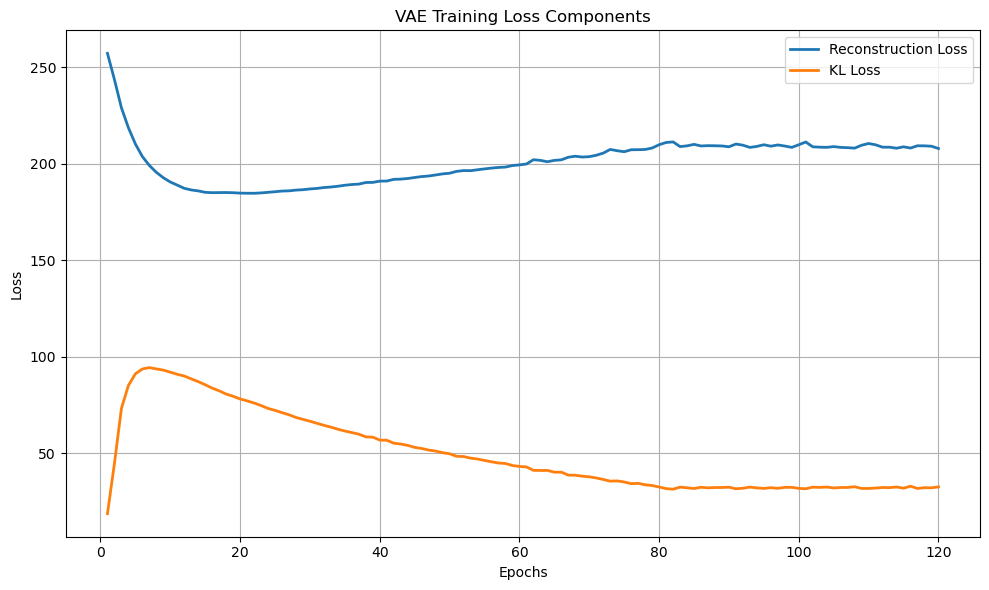

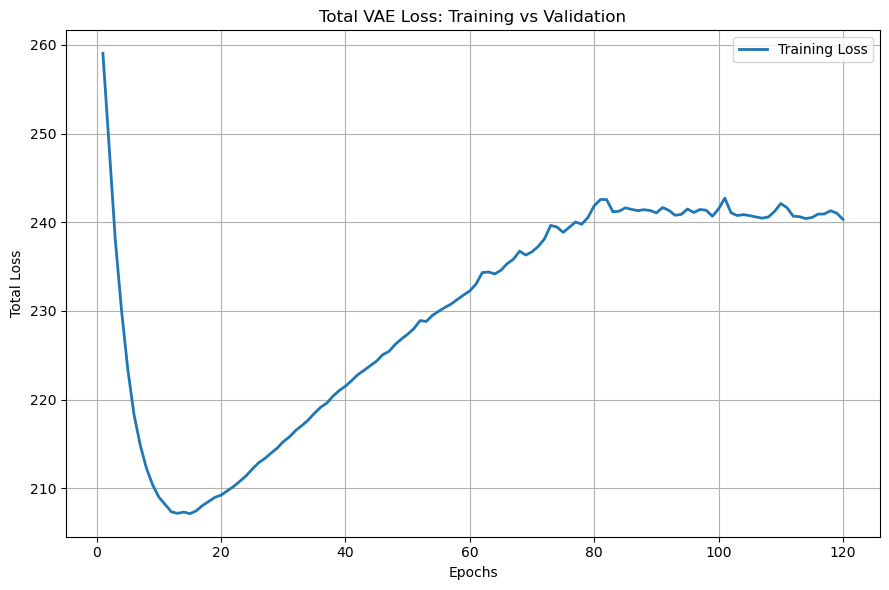

In [12]:
plot_vae_training(history)
plot_total_loss(history)


### 1.4 Generate Km parameter sets

In [13]:
# Condition on class 1 (good models) with TEMPERATURE = 1.0
y_target = tf.constant([1.0], dtype=tf.float32)

x_gen = generate_conditioned(
    decoder, LATENT_DIM, y_target,
    n=N_GENERATE, temperature=TEMPERATURE
)

km_cols = df_pgi.columns.drop("Error")
df_gen_pgi = postprocess_generated(
    x_gen,
    scaler=prep["scalers"]["log_standard"],
    feature_names=km_cols,
)

# Remove any rows with non-positive values (unphysical Km)
df_gen_pgi = df_gen_pgi[(df_gen_pgi > 0).all(axis=1)].reset_index(drop=True)
print(f"Generated {len(df_gen_pgi)} valid Km sets  "
      f"(from {N_GENERATE} sampled, {N_GENERATE - len(df_gen_pgi)} removed)")
df_gen_pgi.head(3)


Generated 2000 valid Km sets  (from 2000 sampled, 0 removed)


,km_substrate1_ACALD,km_product1_ACALD,km_substrate2_ACALD,km_product2_ACALD,km_substrate3_ACALD,km_substrate_ACALDt,km_product_ACALDt,km_substrate1_ACKr,km_product1_ACKr,km_substrate2_ACKr,...,km_substrate1_TKT1,km_product1_TKT1,km_substrate2_TKT1,km_product2_TKT1,km_substrate1_TKT2,km_product1_TKT2,km_substrate2_TKT2,km_product2_TKT2,km_substrate_TPI,km_product_TPI
0,230.599060,0.141343,17.533123,651.599243,0.007159,0.004926,0.003977,2288.339844,93.415466,0.011719,...,5421.192383,233.590576,16.423712,30.196630,6743.020020,5.638404,10.803332,29.215248,84.552223,12.473154
1,1668.583252,0.177556,12.997259,458.098511,0.006762,0.002201,0.002308,154.590561,198.494232,0.015061,...,2602.579346,133.635803,269.146240,75.554871,6086.236328,4.471544,4.983068,44.993919,27.959044,42.062767
2,642.654724,0.119050,15.104580,249.078690,0.002144,0.000650,0.001961,403.371277,351.905548,0.020311,...,3827.176758,155.203461,413.972992,99.724724,18447.996094,14.034540,7.030985,22.169495,59.550911,4.065757


In [14]:
# Save to outputs/ — used by scripts/reproduce_fig2_pgi.py
out_path = "../outputs/ecoli_pgi_km.csv"
df_gen_pgi.to_csv(out_path)
print(f"Saved → {out_path}  ({df_gen_pgi.shape})")


Saved → ../outputs/ecoli_pgi_km.csv  ((2000, 259))


---
## Section 2 — 5-mutant joint robustness (Figures 4, 5, 6)

Here the cVAE is conditioned on **joint** performance across five simultaneous
perturbations: PGI, PGL, RPI, TALA, and PYK (Section 3.1.4).  
A model is labelled class 1 only if it falls in the best 40 % for **every**
perturbation (per-mutant oracle percentile threshold, Table 3).

**Output:** `outputs/ecoli_multimutant_km.csv`


### 2.1 Configuration

In [32]:
# ── Paper constants (Section 3.1.4, Table 3) ──────────────────────────────
THRESHOLD_PER_MUTANT_PCT = 40   # per-mutant ORACLE percentile threshold
N_GENERATE_MM = 2000

DATA_PATHS_MM = {
    "PGI"  : "../data/data_for_training/zeta_PGI_training_pert.csv",
    "PGL"  : "../data/data_for_training/zeta_PGL_training_pert.csv",
    "RPI"  : "../data/data_for_training/zeta_RPI_training_pert.csv",
    "TALA" : "../data/data_for_training/zeta_TALA_training_pert.csv",
    "PYK"  : "../data/data_for_training/zeta_PYK_training_pert.csv",
}

# cVAE architecture — same as Section 1
LATENT_DIM_MM    = 80
BATCH_SIZE_MM    = 100
EPOCHS_MM        = 120
LEARNING_RATE_MM = 5e-4
BETA_MM          = 0.1
MAX_BETA_MM      = 1.0
WARMUP_MM        = 80
TEMPERATURE_MM   = 1.0
# ─────────────────────────────────────────────────────────────────────────


### 2.2 Load and preprocess training data

In [33]:
dfs_mm = {name: pd.read_csv(path, index_col=0) for name, path in DATA_PATHS_MM.items()}

for name, df in dfs_mm.items():
    print(f"{name}: {df.shape[0]} models, KPI range [{df['Error'].min():.4f}, {df['Error'].max():.4f}]")


PGI: 12503 models, KPI range [4.6772, 31.5092]
PGL: 12496 models, KPI range [2.6532, 53.9202]
RPI: 12521 models, KPI range [5.8722, 107.5852]
TALA: 12519 models, KPI range [7.7273, 132.9071]
PYK: 12499 models, KPI range [3.2554, 62.2093]


In [34]:
prep_mm = preprocess_multilabel_dfs(
    df_list=list(dfs_mm.values()),
    percentile_cutoffs=[THRESHOLD_PER_MUTANT_PCT] * len(dfs_mm),
)

X_scaled_mm = prep_mm["X_log_standard"]
y_multi_mm  = prep_mm["y_multilabel"]      # shape (n, 5)

# Joint label: 1 only if model satisfies ALL 5 conditions
y_joint = np.all(y_multi_mm == 1, axis=1).astype(int).reshape(-1, 1)

label_dim_mm = y_joint.shape[1]
input_dim_mm = X_scaled_mm.shape[1]

n_joint = y_joint.sum()
print(f"\nTraining samples        : {len(X_scaled_mm)}")
print(f"Joint class-1 (all 5)   : {n_joint} ({100*n_joint/len(X_scaled_mm):.2f} %)")



Thresholds per label:
----------------------------------------
Label 0: Error ≤ 10.429590  (percentile 40.0)
Label 1: Error ≤ 5.430966  (percentile 40.0)
Label 2: Error ≤ 10.609160  (percentile 40.0)
Label 3: Error ≤ 14.127997  (percentile 40.0)
Label 4: Error ≤ 6.166340  (percentile 40.0)
----------------------------------------

Training samples        : 12443
Joint class-1 (all 5)   : 186 (1.49 %)


### 2.3 Build and train cVAE

In [36]:
reset_environment()

encoder_mm = build_conditional_encoder(
    input_dim=input_dim_mm, label_dim=label_dim_mm, latent_dim=LATENT_DIM_MM,
    hidden_layers=[256, 128, 128], activation="elu", use_label_embedding=True,
)
decoder_mm = build_conditional_decoder(
    input_dim=input_dim_mm, label_dim=label_dim_mm, latent_dim=LATENT_DIM_MM,
    hidden_layers=[128, 128, 256], activation="gelu", output_activation=None,
    use_label_embedding=True,
)
model_mm = ConditionalVAE(
    encoder=encoder_mm, decoder=decoder_mm,
    beta=BETA_MM, max_beta=MAX_BETA_MM,
    warmup_epochs=WARMUP_MM, recon_loss="mse",
)
model_mm.compile(optimizer=tf.keras.optimizers.Adam(LEARNING_RATE_MM))

history_mm = model_mm.fit(
    x=(X_scaled_mm, y_joint),
    y=X_scaled_mm,
    epochs=EPOCHS_MM,
    batch_size=BATCH_SIZE_MM,
    shuffle=True,
    callbacks=[EpochSetter()],
)


[Environment reset] random seed = 42
Epoch 1/120
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - beta: 0.1000 - kl: 19.7760 - loss: 262.4803 - recon: 260.5027
Epoch 2/120
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - beta: 0.1112 - kl: 35.1364 - loss: 251.6165 - recon: 247.7076
Epoch 3/120
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - beta: 0.1225 - kl: 68.3235 - loss: 240.6218 - recon: 232.2522
Epoch 4/120
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - beta: 0.1337 - kl: 85.0275 - loss: 231.0743 - recon: 219.7018
Epoch 5/120
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - beta: 0.1450 - kl: 92.7185 - loss: 223.4196 - recon: 209.9754
Epoch 6/120
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - beta: 0.1562 - kl: 95.4997 - loss: 217.9502 - recon: 203.0284
Epoch 7/120
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - beta: 0.1675 - kl: 96.0876 - loss: 213.8371 - recon: 197.7423
Epoch 8/120
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - beta: 0.1787 - kl: 95.6867 - loss: 211.2576 - recon: 194.1535
Epoch 9/120
125/125 ━━━━━━━

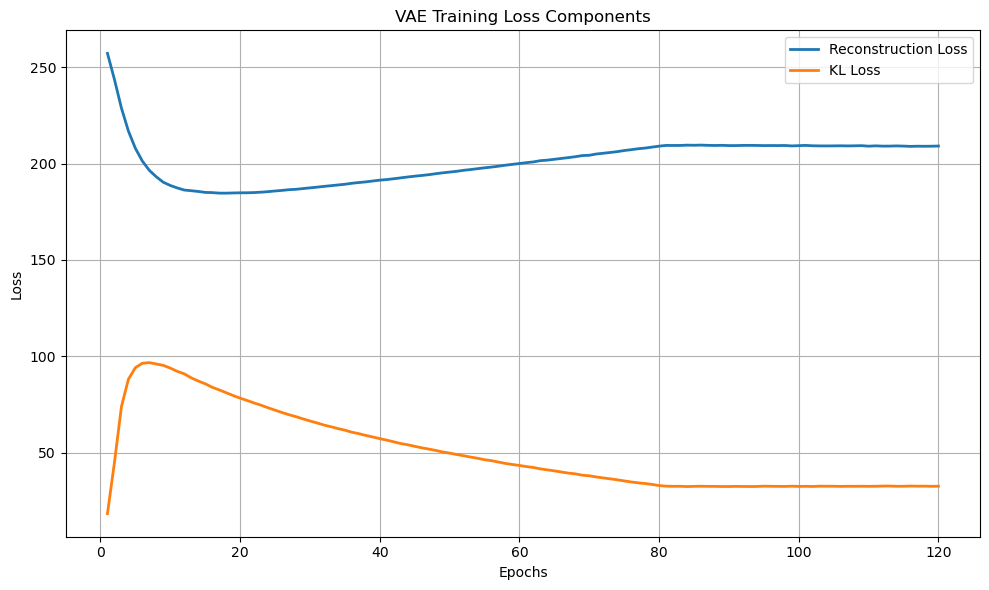

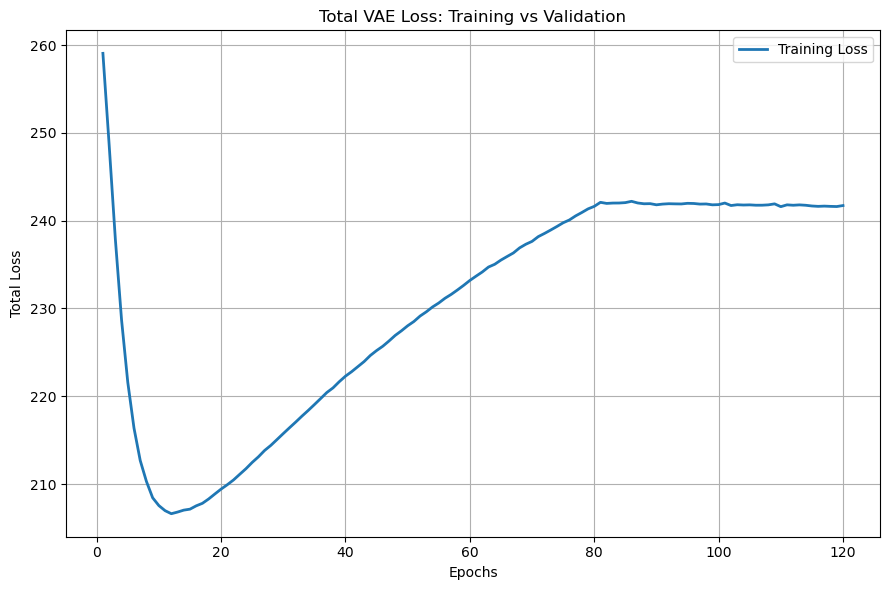

In [37]:
plot_vae_training(history_mm)
plot_total_loss(history_mm)


### 2.4 Generate Km parameter sets

In [38]:
y_target_mm = tf.constant([1.0], dtype=tf.float32)

x_gen_mm = generate_conditioned(
    decoder_mm, LATENT_DIM_MM, y_target_mm,
    n=N_GENERATE_MM, temperature=TEMPERATURE_MM,
)

km_cols_mm = dfs_mm["PGI"].columns.drop("Error")
df_gen_mm = postprocess_generated(
    x_gen_mm,
    scaler=prep_mm["scalers"]["log_standard"],
    feature_names=km_cols_mm,
)

df_gen_mm = df_gen_mm[(df_gen_mm > 0).all(axis=1)].reset_index(drop=True)
print(f"Generated {len(df_gen_mm)} valid Km sets  (from {N_GENERATE_MM} sampled)")


Generated 2000 valid Km sets  (from 2000 sampled)


In [39]:
# Save to outputs/ — used by scripts/reproduce_fig4_5_6_multimutant.py
out_path_mm = "../outputs/ecoli_multimutant_km.csv"
df_gen_mm.to_csv(out_path_mm)
print(f"Saved → {out_path_mm}  ({df_gen_mm.shape})")


Saved → ../outputs/ecoli_multimutant_km.csv  ((2000, 259))


---
## Section 3 — Generalization to unseen perturbations (Figures 7, 8)

The cVAE is trained on **only PGI and TALA** (tighter threshold for PGI, looser
for TALA) to test whether the generated ensemble generalises to four held-out
conditions: PGL, RPI, PYK, and G6PDH2r (Section 3.1.5).

| Condition | KPI threshold | Role |
|-----------|--------------|------|
| PGI  | best 5 %  | training |
| TALA | best 25 % | training |
| PGL, RPI, PYK, G6PDH2r | — | **held-out** |

**Output:** `outputs/ecoli_generalization_km.csv`


### 3.1 Configuration

In [40]:
# ── Paper constants (Section 3.1.5) ───────────────────────────────────────
THRESHOLD_PGI_PCT  = 5     # stringent PGI threshold (best 5 %)
THRESHOLD_TALA_PCT = 25    # permissive TALA threshold (best 25 %)
N_GENERATE_GEN = 2000

DATA_PATH_PGI_GEN  = "../data/data_for_training/zeta_PGI_training_pert.csv"
DATA_PATH_TALA_GEN = "../data/data_for_training/zeta_TALA_training_pert.csv"

# cVAE architecture
LATENT_DIM_GEN    = 80
BATCH_SIZE_GEN    = 100
EPOCHS_GEN        = 120
LEARNING_RATE_GEN = 5e-4
BETA_GEN          = 0.1
MAX_BETA_GEN      = 1.0
WARMUP_GEN        = 80
TEMPERATURE_GEN   = 1.0
# ─────────────────────────────────────────────────────────────────────────


### 3.2 Load and preprocess training data

In [41]:
df_pgi_gen  = pd.read_csv(DATA_PATH_PGI_GEN,  index_col=0)
df_tala_gen = pd.read_csv(DATA_PATH_TALA_GEN, index_col=0)

print(f"PGI  data: {df_pgi_gen.shape[0]}  ORACLE models")
print(f"TALA data: {df_tala_gen.shape[0]} ORACLE models")


PGI  data: 12503  ORACLE models
TALA data: 12519 ORACLE models


In [42]:
prep_gen = preprocess_multilabel_dfs(
    df_list=[df_pgi_gen, df_tala_gen],
    percentile_cutoffs=(THRESHOLD_PGI_PCT, THRESHOLD_TALA_PCT),
)

X_scaled_gen = prep_gen["X_log_standard"]
y_multi_gen  = prep_gen["y_multilabel"]      # shape (n, 2)

# Joint label: 1 only if model is good for BOTH PGI and TALA
y_joint_gen = np.all(y_multi_gen == 1, axis=1).astype(int).reshape(-1, 1)

label_dim_gen = y_joint_gen.shape[1]
input_dim_gen = X_scaled_gen.shape[1]

n_joint_gen = y_joint_gen.sum()
print(f"\nTraining samples          : {len(X_scaled_gen)}")
print(f"Class-1 (PGI ∩ TALA)      : {n_joint_gen} ({100*n_joint_gen/len(X_scaled_gen):.2f} %)")
print(f"PGI threshold             : {prep_gen['thresholds'][0]:.6f}")
print(f"TALA threshold            : {prep_gen['thresholds'][1]:.6f}")



Thresholds per label:
----------------------------------------
Label 0: Error ≤ 7.582914  (percentile 5.0)
Label 1: Error ≤ 13.798286  (percentile 25.0)
----------------------------------------

Training samples          : 12498
Class-1 (PGI ∩ TALA)      : 107 (0.86 %)
PGI threshold             : 7.582914
TALA threshold            : 13.798286


### 3.3 Build and train cVAE

In [44]:
reset_environment()

encoder_gen = build_conditional_encoder(
    input_dim=input_dim_gen, label_dim=label_dim_gen, latent_dim=LATENT_DIM_GEN,
    hidden_layers=[256, 128, 128], activation="elu", use_label_embedding=True,
)
decoder_gen = build_conditional_decoder(
    input_dim=input_dim_gen, label_dim=label_dim_gen, latent_dim=LATENT_DIM_GEN,
    hidden_layers=[128, 128, 256], activation="gelu", output_activation=None,
    use_label_embedding=True,
)
model_gen = ConditionalVAE(
    encoder=encoder_gen, decoder=decoder_gen,
    beta=BETA_GEN, max_beta=MAX_BETA_GEN,
    warmup_epochs=WARMUP_GEN, recon_loss="mse",
)
model_gen.compile(optimizer=tf.keras.optimizers.Adam(LEARNING_RATE_GEN))

history_gen = model_gen.fit(
    x=(X_scaled_gen, y_joint_gen),
    y=X_scaled_gen,
    epochs=EPOCHS_GEN,
    batch_size=BATCH_SIZE_GEN,
    shuffle=True,
    callbacks=[EpochSetter()],
)


[Environment reset] random seed = 42
Epoch 1/120
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - beta: 0.1000 - kl: 19.8724 - loss: 262.6001 - recon: 260.6129
Epoch 2/120
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - beta: 0.1112 - kl: 35.3097 - loss: 251.6447 - recon: 247.7165
Epoch 3/120
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - beta: 0.1225 - kl: 68.2547 - loss: 240.6449 - recon: 232.2837
Epoch 4/120
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - beta: 0.1337 - kl: 86.7367 - loss: 230.5567 - recon: 218.9557
Epoch 5/120
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - beta: 0.1450 - kl: 93.9163 - loss: 222.7577 - recon: 209.1398
Epoch 6/120
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - beta: 0.1562 - kl: 96.3447 - loss: 217.2166 - recon: 202.1627
Epoch 7/120
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - beta: 0.1675 - kl: 96.8945 - loss: 213.1741 - recon: 196.9443
Epoch 8/120
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - beta: 0.1787 - kl: 95.8872 - loss: 210.9527 - recon: 193.8128
Epoch 9/120
125/125 ━━━━━━━

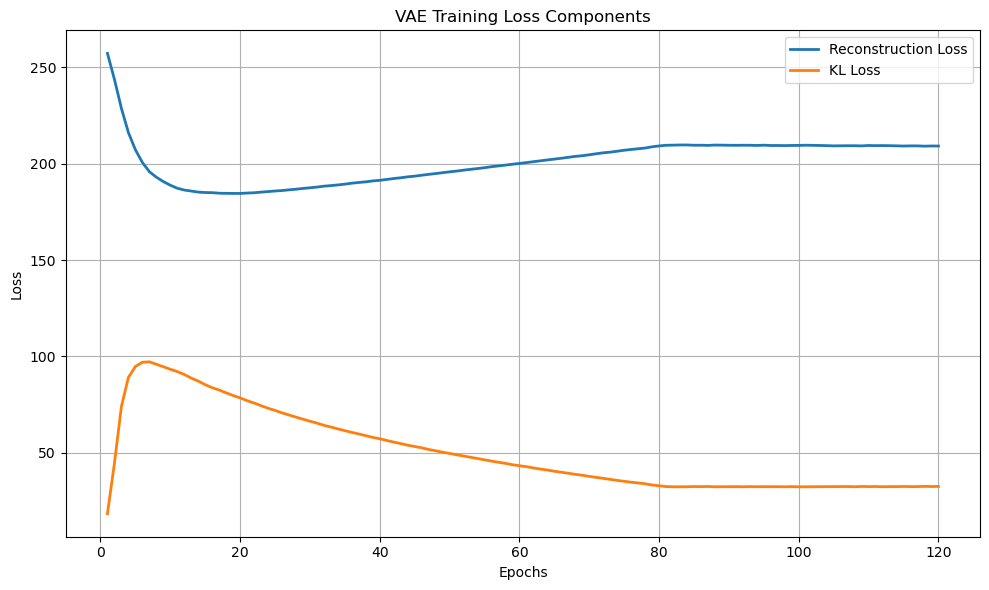

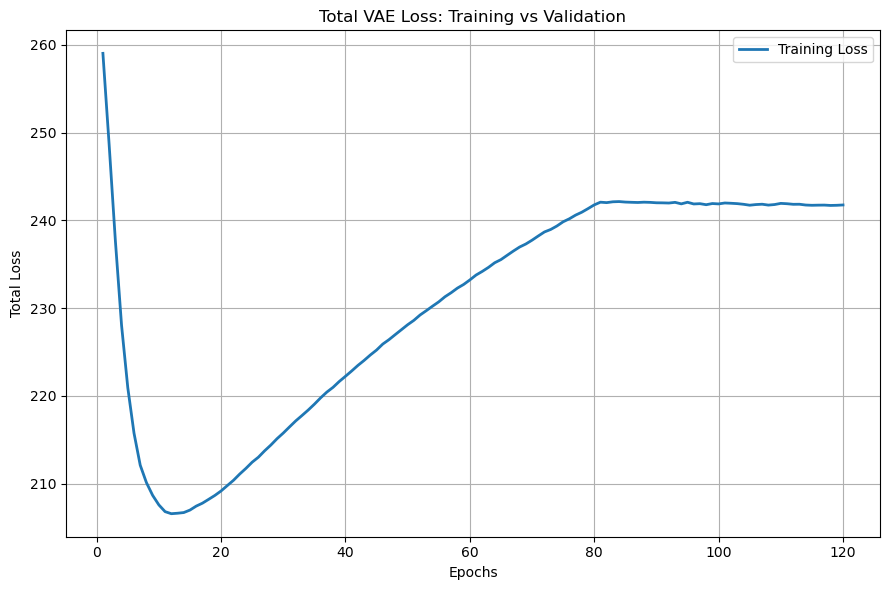

In [29]:
plot_vae_training(history_gen)
plot_total_loss(history_gen)


### 3.4 Generate Km parameter sets

In [45]:
y_target_gen = tf.constant([1.0], dtype=tf.float32)

x_gen_gen = generate_conditioned(
    decoder_gen, LATENT_DIM_GEN, y_target_gen,
    n=N_GENERATE_GEN, temperature=TEMPERATURE_GEN,
)

km_cols_gen = df_pgi_gen.columns.drop("Error")
df_gen_gen = postprocess_generated(
    x_gen_gen,
    scaler=prep_gen["scalers"]["log_standard"],
    feature_names=km_cols_gen,
)

df_gen_gen = df_gen_gen[(df_gen_gen > 0).all(axis=1)].reset_index(drop=True)
print(f"Generated {len(df_gen_gen)} valid Km sets  (from {N_GENERATE_GEN} sampled)")


Generated 2000 valid Km sets  (from 2000 sampled)


In [46]:
# Save to outputs/ — used by scripts/reproduce_fig7_8_generalization.py
out_path_gen = "../outputs/ecoli_generalization_km.csv"
df_gen_gen.to_csv(out_path_gen)
print(f"Saved → {out_path_gen}  ({df_gen_gen.shape})")

print("\n✓ All three E. coli Km files exported:")
print("    outputs/ecoli_pgi_km.csv")
print("    outputs/ecoli_multimutant_km.csv")
print("    outputs/ecoli_generalization_km.csv")


Saved → ../outputs/ecoli_generalization_km.csv  ((2000, 259))

✓ All three E. coli Km files exported:
    outputs/ecoli_pgi_km.csv
    outputs/ecoli_multimutant_km.csv
    outputs/ecoli_generalization_km.csv
